<span style = "font-family: Verdana; font-size: 20px">

#### **Visualization**
</span>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as mtick
from sklearn.manifold import TSNE
from PIL import Image
import openchord as ocd
from os import listdir

import unicodedata

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/modified/viz_pokemon.csv', keep_default_na=False, dtype = {'ID': str})



##### **Colors and functions defining**
</span>

In [4]:
STATS = ['Hp','Attack','Defense','SpecialAttack','SpecialDefense','Speed']

COLOR_TYPES = {'Normal': '#9fa19f',
               'Fighting': '#ff8101',
               'Flying': '#81b9ef',
               'Poison': '#9142cb',
               'Ground': '#925122',
               'Rock': '#a9af82',
               'Bug': '#91a119',
               'Ghost': '#714171',
               'Steel': '#61a1b9',
               'Fire': '#e72829',
               'Water': '#2881f0',
               'Grass': '#3fa22a',
               'Electric': '#fac000',
               'Psychic': '#f0417a',
               'Ice': '#3fcdf3',
               'Dragon': '#5060e2',
               'Dark': '#624d4f',
               'Fairy': '#ef71ef'
               }

COLOR_STATS = {'Hp': "#279555",              
               'Attack': '#c0392b',          
               'Defense': '#d35400',         
               'SpecialAttack': "#3690a4",   
               'SpecialDefense': '#5f27cd',  
               'Speed': "#a043a0",           
                'TotalStats': "#7432a0"
               }

COLOR_EGGGROUPS = {'Monster': '#98734d',
               'Human-Like': '#47b7ae',
               'Water 1': '#6bd1f9',
               'Water 3': '#2271b4',
               'Bug': '#abc229',
               'Mineral': '#979067',
               'Flying': '#90aff1',
               'Amorphous': '#a082cc',
               'Field': '#e5ba65',
               'Water 2': '#4c94ee',
               'Fairy': '#ff9eb9',
               'Ditto': '#b6aad5',
               'Grass': '#83d35a',
               'Dragon': '#5e58bf',
               'No Eggs Discovered': '#efd004',
               }

NUM_GEN = df['Generation'].max()

In [5]:
ICONSPATH = '../Images/Icons'

def transformpath(path):
    if path == f'{ICONSPATH}/Type: Null.png':
        path = f'{ICONSPATH}/Type Null.png'
    elif path == f'{ICONSPATH}/Silvally Type: Normal.png':
        path = f'{ICONSPATH}/Silvally.png'  
    norm_form = 'NFC' if os.name == 'nt' else 'NFD'
    return unicodedata.normalize(norm_form, path)

for name in df['Name'].to_list():
    p = transformpath(f'{ICONSPATH}/{name}.png')
    assert os.path.isfile(p) or os.path.isfile(p), f"Icon not found for '{name}': {p}"

### **Data Overview**

In [6]:
pd.options.display.max_columns = None
df.head()

,ID,Name,Type1,Type2,HiddenAbility,Generation,Hp,Attack,Defense,SpecialAttack,SpecialDefense,Speed,TotalStats,Weight,Height,GenderProbM,Category,CatchRate,EggCycles,LevelingRate,BaseFriendship,IsLegendary,IsMythical,HasMega,EvoStage,TotalEvoStages,PreevoName,DamageFromNormal,DamageFromFighting,DamageFromFlying,DamageFromPoison,DamageFromGround,DamageFromRock,DamageFromBug,DamageFromGhost,DamageFromSteel,DamageFromFire,DamageFromWater,DamageFromGrass,DamageFromElectric,DamageFromPsychic,DamageFromIce,DamageFromDragon,DamageFromDark,DamageFromFairy,Ability1,Ability2,FightsWon,TotalFights,WinPercentage
0,1,Bulbasaur,Grass,Poison,Chlorophyll,1,45.0,49.0,49.0,65.0,65.0,45.0,318.0,6.9,0.7,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,0,1,3,No Preevolution,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.5,0.25,0.5,2.0,2.0,1.0,1.0,0.5,Overgrow,None,37,133,0.278195
1,2,Ivysaur,Grass,Poison,Chlorophyll,1,60.0,62.0,63.0,80.0,80.0,60.0,405.0,13.0,1.0,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,0,2,3,Bulbasaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.5,0.25,0.5,2.0,2.0,1.0,1.0,0.5,Overgrow,None,46,121,0.380165
2,3,Venusaur,Grass,Poison,Chlorophyll,1,80.0,82.0,83.0,100.0,100.0,80.0,525.0,100.0,2.0,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,1,3,3,Ivysaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.5,0.25,0.5,2.0,2.0,1.0,1.0,0.5,Overgrow,None,89,132,0.674242
3,4,Mega Venusaur,Grass,Poison,None,1,80.0,100.0,123.0,122.0,120.0,80.0,625.0,155.5,2.4,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,1,3,3,Venusaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.25,0.5,2.0,1.0,1.0,1.0,0.5,Thick Fat,None,70,125,0.560000
4,5,Charmander,Fire,,Solar Power,1,39.0,52.0,43.0,60.0,50.0,65.0,309.0,8.5,0.6,0.875,Lizard Pokémon,45,20,Medium Slow,70,0,0,0,1,3,No Preevolution,1.0,1.0,1.0,1.0,2.0,2.0,0.5,1.0,0.5,0.5,2.0,0.50,1.0,1.0,0.5,1.0,1.0,0.5,Blaze,None,55,112,0.491071




**Variable Classification**

In [7]:
numeric_columns = ['Generation', 
                   'Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed', 'TotalStats',
                   'Height', 'Weight', 'GenderProbM', 'CatchRate', 'EggCycles',
                   'BaseFriendship', 'TotalEvoStages',
                   'FightsWon', 'TotalFights', 'WinPercentage',
                   'DamageFromNormal', 'DamageFromFighting', 'DamageFromFlying', 'DamageFromPoison',
                   'DamageFromGround', 'DamageFromRock', 'DamageFromBug', 'DamageFromGhost',
                   'DamageFromSteel', 'DamageFromFire', 'DamageFromWater', 'DamageFromGrass',
                   'DamageFromElectric', 'DamageFromPsychic', 'DamageFromIce', 'DamageFromDragon', 
                   'DamageFromDark', 'DamageFromFairy']

categorical_columns = ['Name', 'Type1', 'Type2', 'Ability1', 'Ability2', 'HiddenAbility',
                       'Category', 'EggGroup1', 'EggGroup2', 
                       'LevelingRate', 'PreevoName']

binary_columns = ['IsLegendary', 'IsMythical', 
                  'HasMega', 'IsMega',
                  'NoGender']

ordinal_columns = []



##### **Numerical Features**

In [8]:
def plot_histograms(df: pd.DataFrame, numerical_cols: list, cols_per_row: int = 3):
    n = len(numerical_cols)
    rows = (n + cols_per_row - 1) // cols_per_row 
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 5, rows * 4))
    if n > 0:
        axes = np.ravel(axes) if rows > 1 or cols_per_row > 1 else np.array([axes])

    for i, col in enumerate(numerical_cols):
        ax = axes[i]
        data = df[col].dropna() 
        
        if data.empty:
            ax.text(0.5, 0.5, "NaN", ha="center", transform=ax.transAxes)
            ax.set_title(col, fontsize=11, fontweight='bold')
            ax.axis("off")
            continue
        sns.histplot(data, bins=30, ax=ax, color="#4a81bf", edgecolor="white")
        ax.set_title(f"Distribution of {col}", fontsize=11, fontweight='bold')
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel("Count", fontsize=10)

        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout() 
    plt.show()

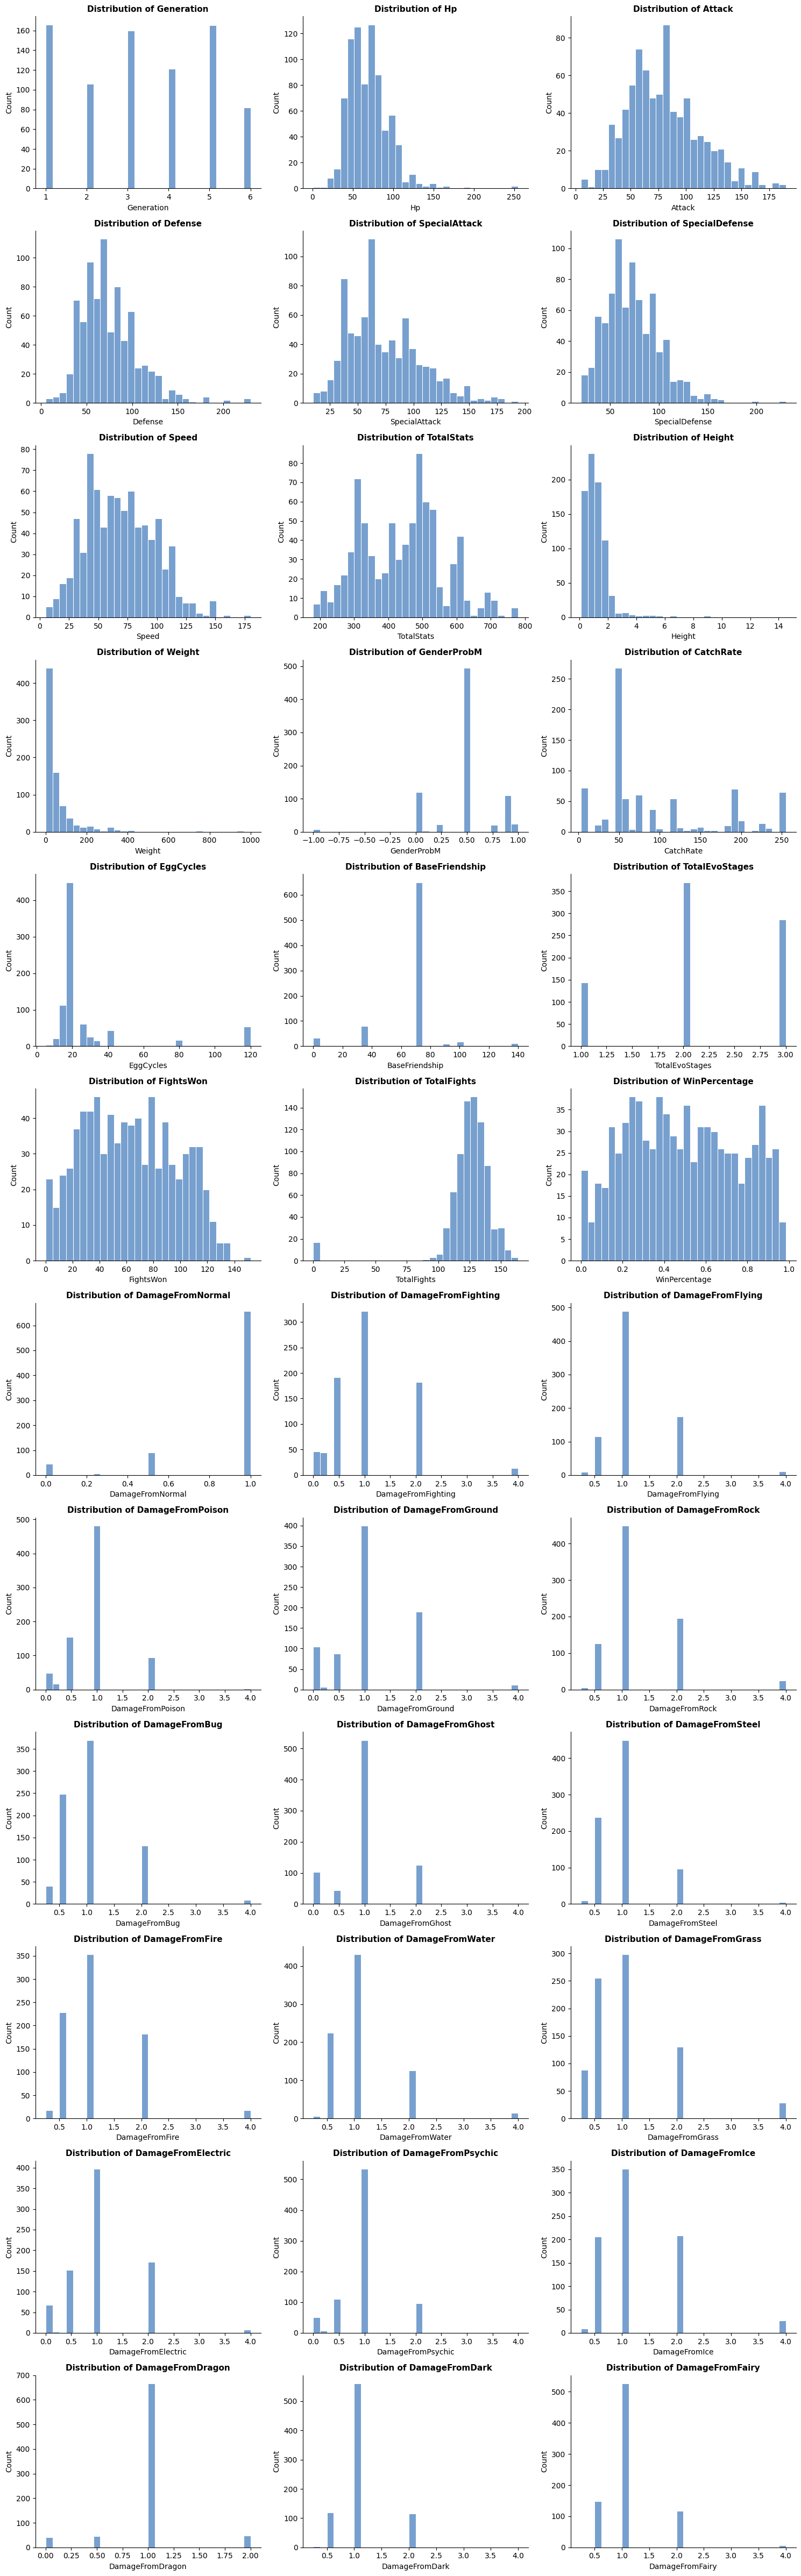

In [9]:
plot_histograms(df, numeric_columns, cols_per_row=3)



**Number of Pokémon by Type/Generation**

In [10]:
type1_counts = df["Type1"].value_counts().reset_index()
type2_counts = df["Type2"].value_counts().reset_index()

type1_counts.columns = ["Type1", "Count_Type1"]
type2_counts.columns = ["Type2", "Count_Type2"]

result = pd.concat([type1_counts, type2_counts], axis=1)
result

,Type1,Count_Type1,Type2,Count_Type2
0,Water,112.0,,386
1,Normal,98.0,Flying,97
2,Grass,70.0,Ground,35
3,Bug,69.0,Poison,34
4,Psychic,57.0,Psychic,33
5,Fire,52.0,Fighting,26
6,Electric,44.0,Grass,25
7,Rock,44.0,Fairy,23
8,Dragon,32.0,Steel,22
9,Ground,32.0,Dark,20


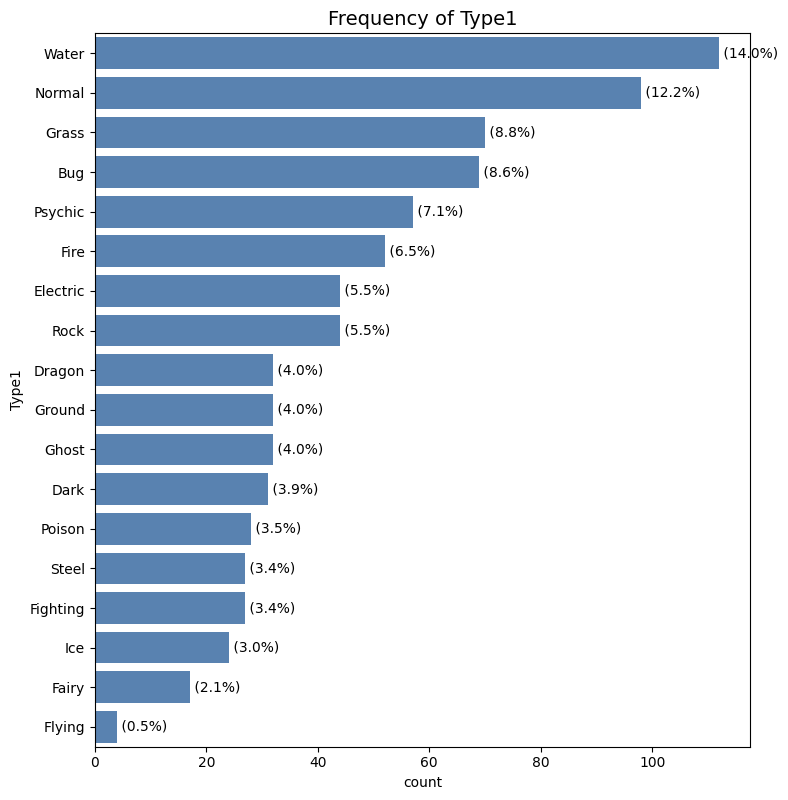

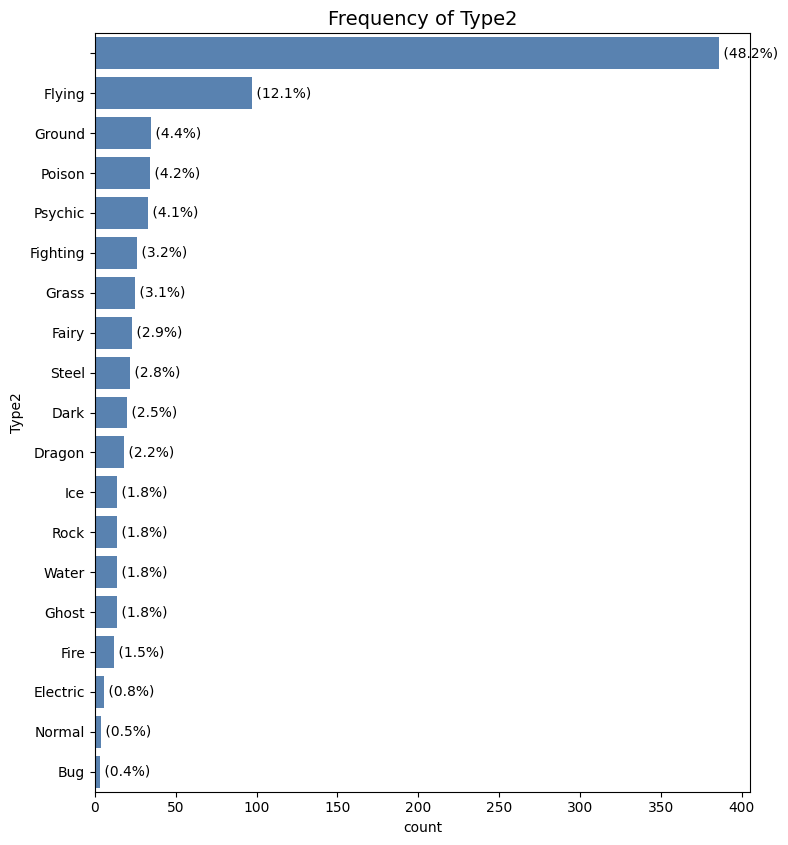

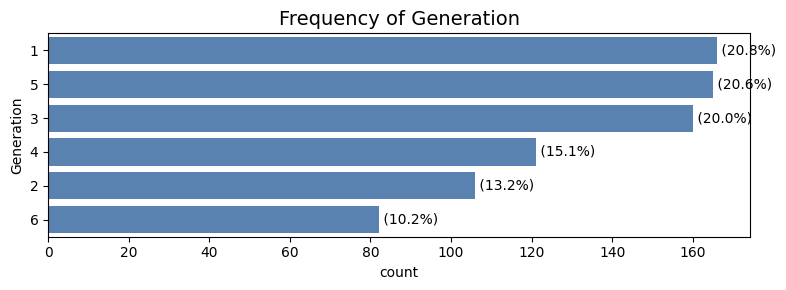

In [11]:
def plot_categorical(df: pd.DataFrame, categorical_cols):
    for col in categorical_cols:
        if col not in df.columns:
            print(f"Warning: Column '{col}' does not exist in the DataFrame and was skipped.")
            continue

        N_categories = df[col].nunique()
        dynamic_height = max(3, N_categories * 0.45) 
        plt.figure(figsize=(8, dynamic_height)) 

        order = df[col].value_counts().index

        sns.countplot(data=df, y=col, order=order, color='#4a81bf' )
        total = len(df)
        plt.title(f'Frequency of {col}', fontsize=14)
        plt.ylabel(col)
        
        for index, value in enumerate(df[col].value_counts()):
            percentage = f' ({value / total:.1%})'
            plt.text(value, index, percentage, va='center', fontsize=10)
        plt.tight_layout()
        plt.show()

col = ['Type1', 'Type2', 'Generation']
    
plot_categorical(df, col)

In [12]:
filter_df = df.copy()
filter_df['Type2'] = filter_df.apply(lambda row: '' if row['Type1'] == row['Type2'] else row['Type2'], axis=1)

melted_df = filter_df.melt(id_vars=['Generation'], value_vars=['Type1', 'Type2'], value_name='Type')
melted_df = melted_df.dropna(subset=['Type'])
melted_df = melted_df[melted_df['Type'] != '']

heatmap_data = pd.crosstab(index=melted_df['Type'], columns=melted_df['Generation'])

gen_mapping = {1: 'I', 2: 'II', 3: 'III', 4: 'IV', 5: 'V', 6: 'VI', 7: 'VII', 8: 'VIII'}
heatmap_data.columns = [gen_mapping.get(c, c) for c in heatmap_data.columns]

sorted_idx = heatmap_data.sum(axis=1).sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[sorted_idx]

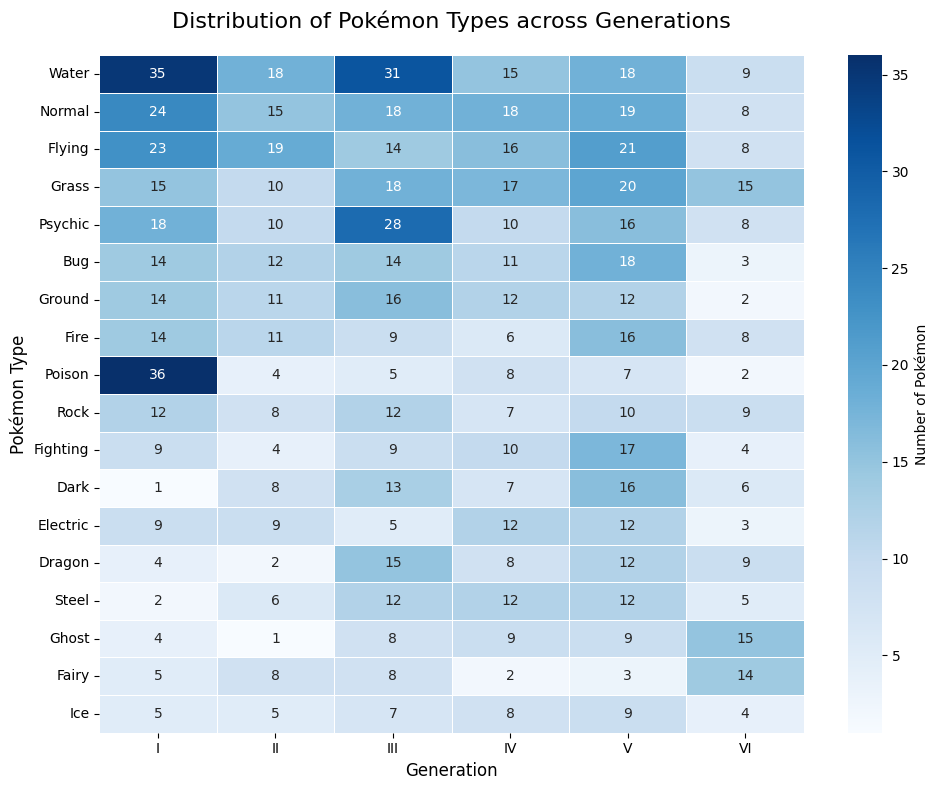

In [13]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    linewidths=0.5, 
    linecolor='white',
    cbar_kws={'label': 'Number of Pokémon'}
)

plt.title('Distribution of Pokémon Types across Generations', fontsize=16, pad=20)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Pokémon Type', fontsize=12)
plt.tight_layout()
plt.show()

<span style = "font-family: Verdana; font-size: 20px">

**Basic Stats**

<span style = "font-family: Verdana; font-size: 16px">

**Top 10 Pokémons with highest value in each stat**

In [14]:
for stat in STATS:
    print(stat)
    display(df[['Name', stat]].sort_values(stat, ascending=False).head(10))

Hp


,Name,Hp
261,Blissey,255.0
121,Chansey,250.0
217,Wobbuffet,190.0
351,Wailord,170.0
655,Alomomola,165.0
155,Snorlax,160.0
544,Giratina Altered Forme,150.0
473,Drifblim,150.0
545,Giratina Origin Forme,150.0
313,Slaking,150.0


Attack


,Name,Attack
163,Mega Mewtwo X,190.0
232,Mega Heracross,185.0
424,Primal Groudon,180.0
426,Mega Rayquaza,180.0
429,DeoxysAttack Forme,180.0
711,Kyurem Black Kyurem,170.0
494,Mega Garchomp,170.0
527,Mega Gallade,165.0
387,Mega Banette,165.0
454,Rampardos,165.0


Defense


...

,Name,SpecialAttack
164,Mega Mewtwo Y,194.0
429,DeoxysAttack Forme,180.0
426,Mega Rayquaza,180.0
422,Primal Kyogre,180.0
71,Mega Alakazam,175.0
712,Kyurem White Kyurem,170.0
102,Mega Gengar,170.0
798,Hoopa Unbound,170.0
196,Mega Ampharos,165.0
306,Mega Gardevoir,165.0


SpecialDefense


,Name,SpecialDefense
230,Shuckle,230.0
415,Regice,200.0
422,Primal Kyogre,160.0
430,Deoxys Defense Forme,160.0
739,Florges,154.0
270,Ho-oh,154.0
269,Lugia,154.0
418,Mega Latias,150.0
773,Carbink,150.0
416,Registeel,150.0


Speed


,Name,Speed
431,Deoxys Speed Forme,180.0
315,Ninjask,160.0
154,Mega Aerodactyl,150.0
109,Electrode,150.0
71,Mega Alakazam,150.0
428,Deoxys Normal Forme,150.0
429,DeoxysAttack Forme,150.0
19,Mega Beedrill,145.0
678,Accelgor,145.0
275,Mega Sceptile,145.0


<span style = "font-family: Verdana; font-size: 16px">

**Basic stat distribution**

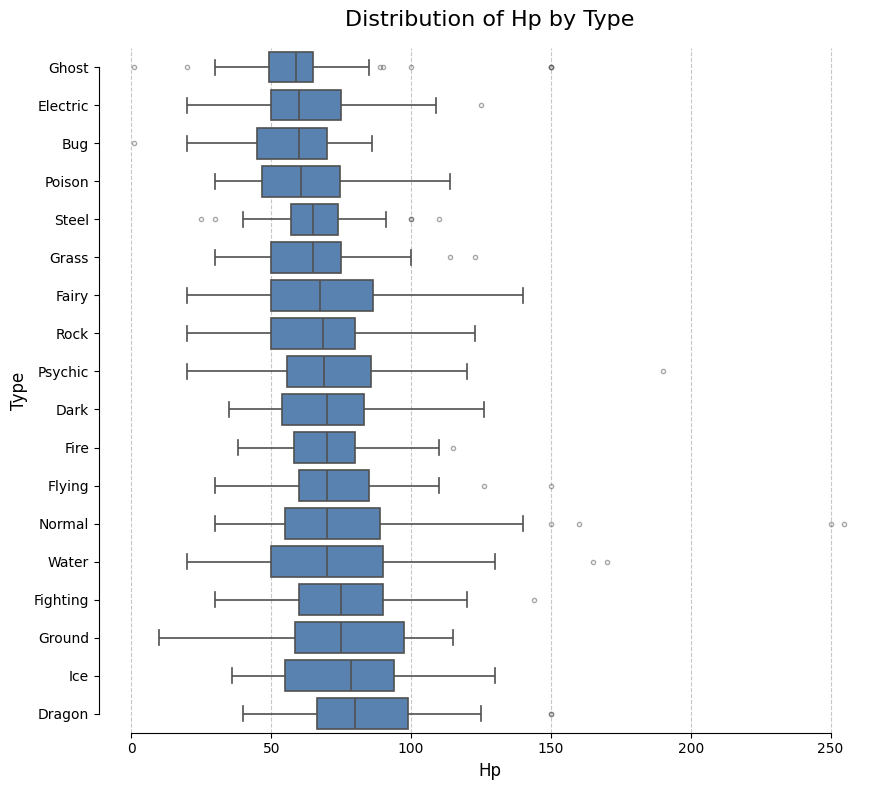

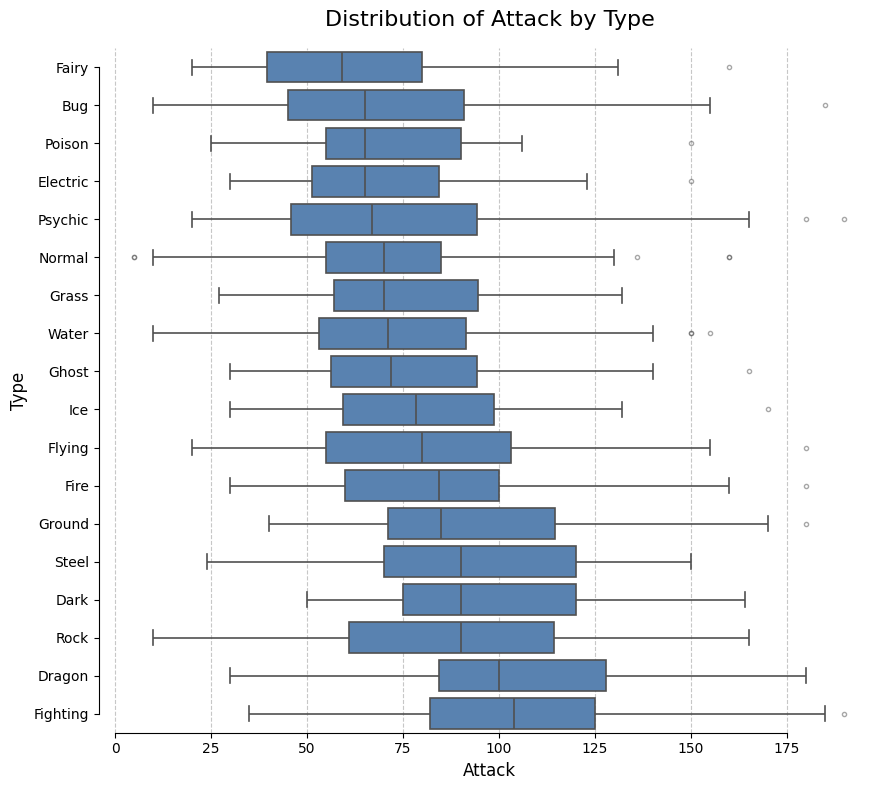

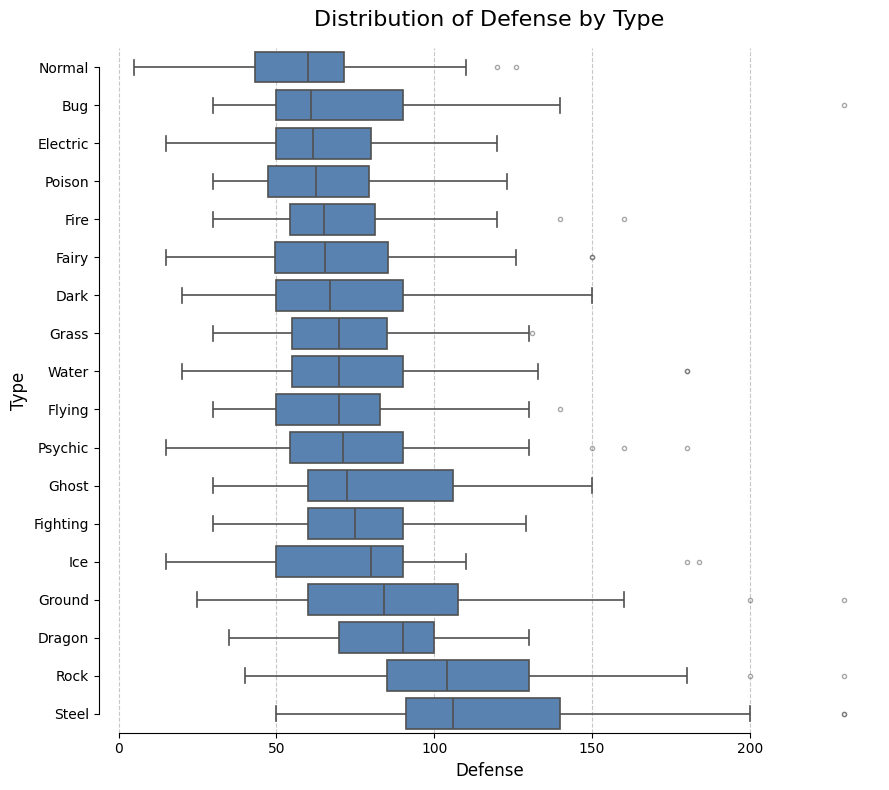

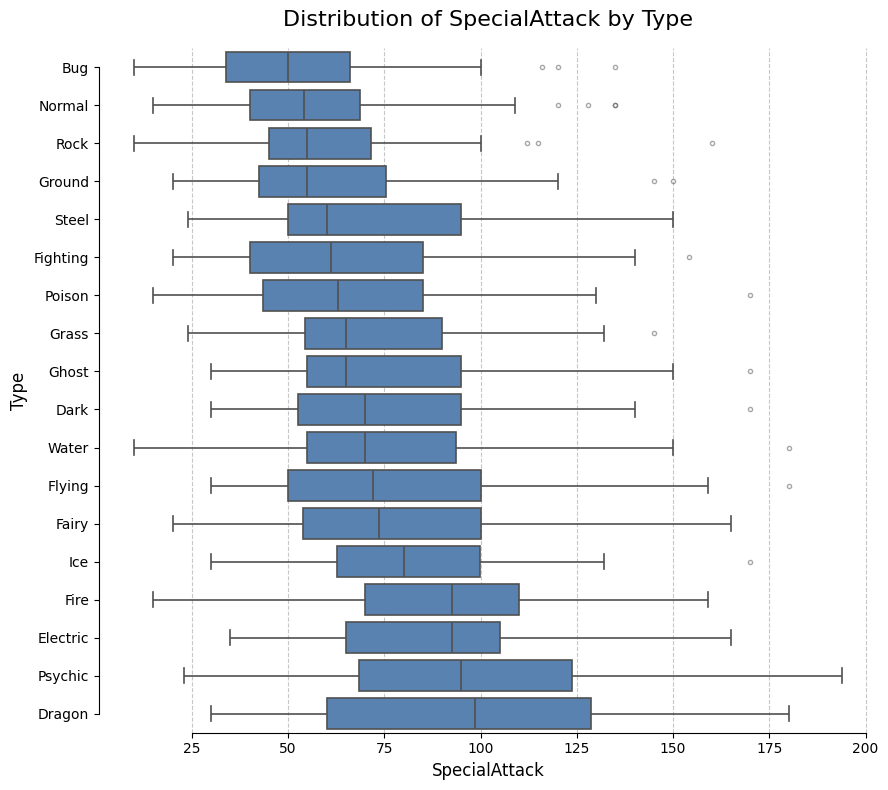

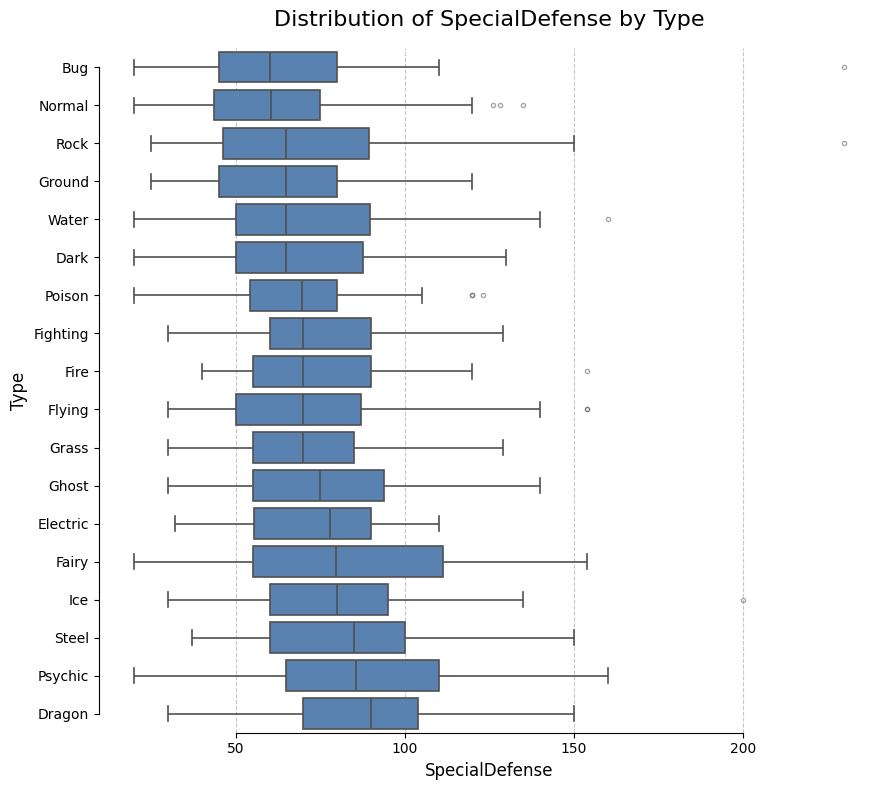

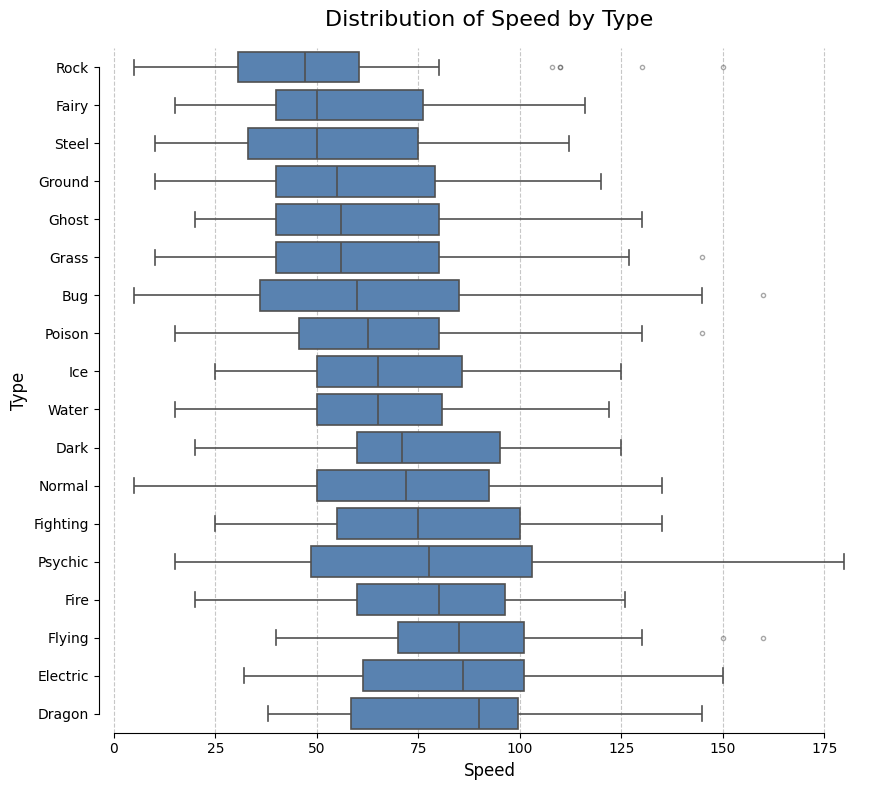

In [15]:
def stat_boxplot(data, stat):
    melted_df = data.melt(
        id_vars=[stat], 
        value_vars=['Type1', 'Type2'], 
        value_name='Type'
    )
    
    melted_df['Type'] = melted_df['Type'].astype(str)
    melted_df['Type'] = melted_df['Type'].str.strip()
    
    filter_condition = (~melted_df['Type'].isin(['nan', 'None', '']))
    melted_df = melted_df[filter_condition]
    sorted_order = melted_df.groupby('Type')[stat].median().sort_values(ascending=True).index

    plt.figure(figsize=(9, 8))
    sns.boxplot(
        data=melted_df,
        x=stat,
        y='Type',
        order=sorted_order,
        color='#4a81bf',
        linewidth=1.2,
        fliersize=3,
        flierprops={'marker': 'o', 'alpha': 0.5}
    )

    plt.title(f'Distribution of {stat} by Type', fontsize=16,  pad=16)
    plt.xlabel(stat, fontsize=12)
    plt.ylabel('Type', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()
    
stat_cols = STATS.copy()
for stat in stat_cols:
    stat_boxplot(df, stat)

In [16]:
max_mean_stat = 0
for t in COLOR_TYPES.keys():
    fig = go.Figure()
    data_type_1 = df.loc[df['Type1'] == t]
    data_type_2 = df.loc[df['Type2'] == t]
    total_data_type = pd.concat([data_type_1, data_type_2])
    mean_stats = [total_data_type[x].mean() for x in STATS]
    for elem in mean_stats:
        if elem > max_mean_stat:
            max_mean_stat = elem

In [17]:
df_plot = mean_values_df.copy()

df_plot = df_plot.rename(columns={
    'SpecialAttack': 'Sp. Atk',
    'SpecialDefense': 'Sp. Def'
})

plt.figure(figsize=(10, 8)) 

ax = sns.heatmap(
    df_plot, 
    annot=True,       
    fmt='.1f',        
    cmap='RdPu',      
    linewidths=.5,    
    cbar_kws={'label': 'Mean Value'} 
)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title('Mean Statistics by Pokémon Type', pad=20, fontsize=14)

plt.tight_layout()
plt.show()
# fig.savefig('../Images/Graphics/MeanStatsType.png', bbox_inches='tight')

NameError: name 'mean_values_df' is not defined

In [ ]:
for stat in STATS:
    fig = px.bar(
        mean_values_df[stat], 
        labels=dict(index="Type", value=f"Mean {stat}")
    )
    fig.update_traces(marker_color='#3690a4')
    
    fig.update_layout(
        showlegend=False,
        width=850,
        plot_bgcolor='white',
        title = dict(
            text = f"Mean {stat} by Type", 
            font = dict(size = 16)
        ),
        title_x = 0.5,
        yaxis_range = [0, max_mean_stat],
        xaxis = dict(
            tickangle=-45,
            categoryorder = 'total descending'
        )
    )
    fig.update_xaxes(showline=True, linewidth=1, linecolor='black', mirror=True)
    fig.update_yaxes(showline=True, linewidth=1, linecolor='black', mirror=True)
    
    fig.show()

<span style = "font-family: Verdana; font-size: 18px">

**Physical/Special Offensive/Defensive stat scatter density**

<span style = "font-family: Verdana; font-size: 16px">

Chỉ nhìn vào một chỉ số duy nhất thì khó mà kết luận được Pokémon đó có thực sự tốt hay không, vì nó có thể cao ở chỉ số này nhưng lại thấp ở chỉ số khác. Do đó trong cộng đồng có một thuật ngữ là `sweeper` và `wall`. `Sweeper` là những Pokémon có chỉ số tấn công cao, giúp chúng có thể nhanh chóng hạ gục đối thủ. Còn `wall` là những Pokémon có chỉ số phòng thủ cao.

Do đó chúng ta sẽ giả định các chỉ số trên được tính bằng công thức sau:
- Physical Offensive (Physical Sweeper) = $\sqrt{Attack*Speed}$
- Special Offensive (Special Sweeper) = $\sqrt{Special Attack*Speed}$
- Physical Defensive (Physical Wall) = $\sqrt{Defense*HP}$
- Special Defensive (Special Wall) = $\sqrt{Special Defense*HP}$

Lưu ý: Những chỉ số này sẽ chỉ xuất hiện để phục vụ việc trực quan hoá, không dùng để huấn luyện mô hình vì có khả năng gây đa cộng tuyến
</span>

In [ ]:
def density_scatter(stat1, stat2, colorbase, colorend, titleadd):
    fig = go.Figure()
    
    fig = px.scatter(
        data,
        x = stat1,
        y = stat2,
        marginal_x = 'histogram',
        marginal_y = 'histogram',
        hover_name= 'Name',
        color_discrete_sequence=[colorend]
        )
    
    name = 'Name'
    
    for i in range(data.shape[0]):
        fig.add_layout_image(
            x = data.at[i, stat1],
            y = data.at[i, stat2],
            source = Image.open(transformpath(f'{ICONSPATH}/{data.at[i, name]}.png')),
            xref = "x",
            yref = "y",
            sizex = 7,
            sizey = 7,
            xanchor = "center",
            yanchor = "middle",
        )
        
    fig.update_traces(
        marker=dict(
            size = 0.1,
            opacity = 0.0,
            color = (data[stat1] * data[stat1] + data[stat2] * data[stat2]).apply(np.sqrt),
            colorscale = [[0, colorbase], [1, colorend]],
            line = dict(
                width = 1,
                color = (data[stat1] * data[stat1] + data[stat2] * data[stat2]).apply(np.sqrt),
                colorscale = [[0, colorbase], [1, colorend]]
            )
        ),
        selector = dict(mode = 'markers')
    )

    x = data[stat1]
    y = data[stat2]
    # names = data['Name']
    
    # print((x.max()-x.min())/5)
    
    fig.add_trace(go.Histogram2d(
        x = x,
        y = y,
        colorscale = [[0, colorbase], [1, colorend]],
        zmax = None,
        nbinsx = int((x.max()-x.min())/5),
        nbinsy = int((y.max()-y.min())/5),
        zauto = True,
        hoverinfo = 'skip'    
        )
    )
    
    fig.update_layout(
        xaxis = dict(
            ticks = '',
            showgrid = False,
            zeroline = False,
            nticks = 20
        ),
        yaxis = dict(
            ticks = '',
            showgrid = False,
            zeroline = False,
            nticks = 20
        ),
        autosize = False,
        width = 1000,
        height = 1000,
        hovermode = 'closest',
        xaxis_title = dict(text = stat1),
        yaxis_title = dict(text = stat2),
        title = dict(
            text =  f'<br>Pokémon {titleadd} ({stat1} vs {stat2})',
            font = dict(size = 16)
        ),
        title_x = 0.5,
        # plot_bgcolor = 'light_blue'
        coloraxis_colorbar = dict(
            title = 'Population',
            tickvals = [6, 7, 8, 9],
            ticktext = ['1M', '10M', '100M', '1B']
        )
    )
    x1_, x2_ = 0.91, 0.915
    y1_, y2_ = 0.91, 0.915
    
    fig.layout.xaxis.domain = (0, x1_)  #type: ignore
    fig.layout.xaxis2.domain = (x2_, 1) #type: ignore
    fig.layout.xaxis3.domain = (0, x1_) #type: ignore
    fig.layout.xaxis4.domain = (x2_, 1) #type: ignore
    fig.layout.yaxis.domain = (0, y1_)  #type: ignore
    fig.layout.yaxis2.domain = (0, y1_) #type: ignore
    fig.layout.yaxis3.domain = (y2_, 1) #type: ignore
    fig.layout.yaxis4.domain = (y2_, 1) #type: ignore
    
    fig.update(layout_coloraxis_showscale = False)
    
    fig.update_traces(showlegend = False)
    fig.update(layout_showlegend = False)
    
    fig.show()
    fig.write_image(f"pokemon/Images/Graphics/{titleadd}.png")
    
density_scatter("Speed", "Attack", "#ffffff", "#ff0000", 'Physical Offensiveness')
density_scatter("Speed", "SpecialAttack", "#ffffff", "#ffa500", 'Special Offensiveness')
density_scatter("Hp", "Defense", "#ffffff", "#32b000", 'Physical Defensiveness')
density_scatter("Hp", "SpecialDefense", "#ffffff", "#0000ff", 'Special Defensiveness')

<span style = "font-family: Verdana; font-size: 16px">

**Top 10 Pokémons with highest value in Physical/Special Offensive/Defensive stat**

In [ ]:
data['PhysicalOffensiveness'] = (data['Attack'] * data['Speed']).apply(np.sqrt)
data['SpecialOffensiveness'] = (data['SpecialAttack'] * data['Speed']).apply(np.sqrt)
data['PhysiscalDefensiveness'] = (data['Defense'] * data['Hp']).apply(np.sqrt)
data['SpecialDefensiveness'] = (data['SpecialDefense'] * data['Hp']).apply(np.sqrt)

for stat in ['PhysicalOffensiveness', 'SpecialOffensiveness', 'PhysiscalDefensiveness', 'SpecialDefensiveness']:
    print(stat)
    display(data[['Name', stat]].sort_values(stat, ascending=False).head(10))

PhysicalOffensiveness


,Name,PhysicalOffensiveness
429,DeoxysAttack Forme,164.316767
163,Mega Mewtwo X,157.162336
428,Deoxys Normal Forme,150.000000
19,Mega Beedrill,147.478812
164,Mega Mewtwo Y,144.913767
426,Mega Rayquaza,143.874946
154,Mega Aerodactyl,142.302495
476,Mega Lopunny,135.499077
527,Mega Gallade,134.721936
796,Mega Diancie,132.664992


SpecialOffensiveness


,Name,SpecialOffensiveness
164,Mega Mewtwo Y,164.802913
429,DeoxysAttack Forme,164.316767
71,Mega Alakazam,162.018517
428,Deoxys Normal Forme,150.000000
102,Mega Gengar,148.660687
275,Mega Sceptile,145.000000
426,Mega Rayquaza,143.874946
163,Mega Mewtwo X,141.492049
162,Mewtwo,141.492049
339,Mega Manectric,135.000000


PhysiscalDefensiveness


,Name,PhysiscalDefensiveness
544,Giratina Altered Forme,134.164079
789,Avalugg,132.211951
224,Mega Steelix,131.339255
87,Mega Slowbro,130.766968
333,Mega Aggron,126.885775
414,Regirock,126.491106
424,Primal Groudon,126.491106
313,Slaking,122.474487
268,Mega Tyranitar,122.474487
545,Giratina Origin Forme,122.474487


SpecialDefensiveness


,Name,SpecialDefensiveness
261,Blissey,185.539753
121,Chansey,162.018517
544,Giratina Altered Forme,134.164079
155,Snorlax,132.664992
270,Ho-oh,127.765410
269,Lugia,127.765410
415,Regice,126.491106
422,Primal Kyogre,126.491106
545,Giratina Origin Forme,122.474487
546,Cresselia,120.000000


<span style = "font-family: Verdana; font-size: 16px">

**Stats summary**

In [ ]:
for stat in STATS:
    print(f"Stat: {stat}")
    print(f"\t- The type with the greatest {stat} is {new_mean_values_df[stat].idxmax()} with a value of {new_mean_values_df[stat].max()}.")
    print(f"\t- The type with the lowest {stat} is {new_mean_values_df[stat].idxmin()} with a value of {new_mean_values_df[stat].min()}.")
    print(f"\t- This is {abs(new_mean_values_df[stat].max() - new_mean_values_df[stat].min())} units greater, or {abs(new_mean_values_df[stat].max()/new_mean_values_df[stat].min())} times greater.")

final_mean_values_df = new_mean_values_df.mean(axis=1)
print("\n")
print(f"The type with the greatest mean statistics is {final_mean_values_df.idxmax()} with a value of {final_mean_values_df.max()}.")
print(f"The type with the lowest mean statistics is {final_mean_values_df.idxmin()} with a value of {final_mean_values_df.min()}.")
print(f"This is {abs(final_mean_values_df.max() - final_mean_values_df.min())} units greater, or {abs(final_mean_values_df.max()/final_mean_values_df.min())} times greater.")

Stat: Hp
	- The type with the greatest Hp is Normal with a value of 80.01538461538462.
	- The type with the lowest Hp is Bug with a value of 53.1.
	- This is 26.915384615384617 units greater, or 1.5068810662031 times greater.
Stat: Attack
	- The type with the greatest Attack is Fighting with a value of 106.0.
	- The type with the lowest Attack is Bug with a value of 56.3.
	- This is 49.7 units greater, or 1.882770870337478 times greater.
Stat: Defense
	- The type with the greatest Defense is Rock with a value of 119.6086956521739.
	- The type with the lowest Defense is Electric with a value of 57.666666666666664.
	- This is 61.94202898550724 units greater, or 2.0741392309625533 times greater.
Stat: SpecialAttack
	- The type with the greatest SpecialAttack is Psychic with a value of 93.66197183098592.
	- The type with the lowest SpecialAttack is Bug with a value of 40.4.
	- This is 53.26197183098592 units greater, or 2.31836563938084 times greater.
Stat: SpecialDefense
	- The type with 

<span style = "font-family: Verdana; font-size: 16px">

**Total Stats**

In [ ]:
data['TotalStats'].value_counts()

TotalStats
600.0    37
405.0    25
500.0    25
580.0    24
300.0    19
         ..
194.0     1
565.0     1
467.0     1
302.0     1
514.0     1
Name: count, Length: 198, dtype: int64

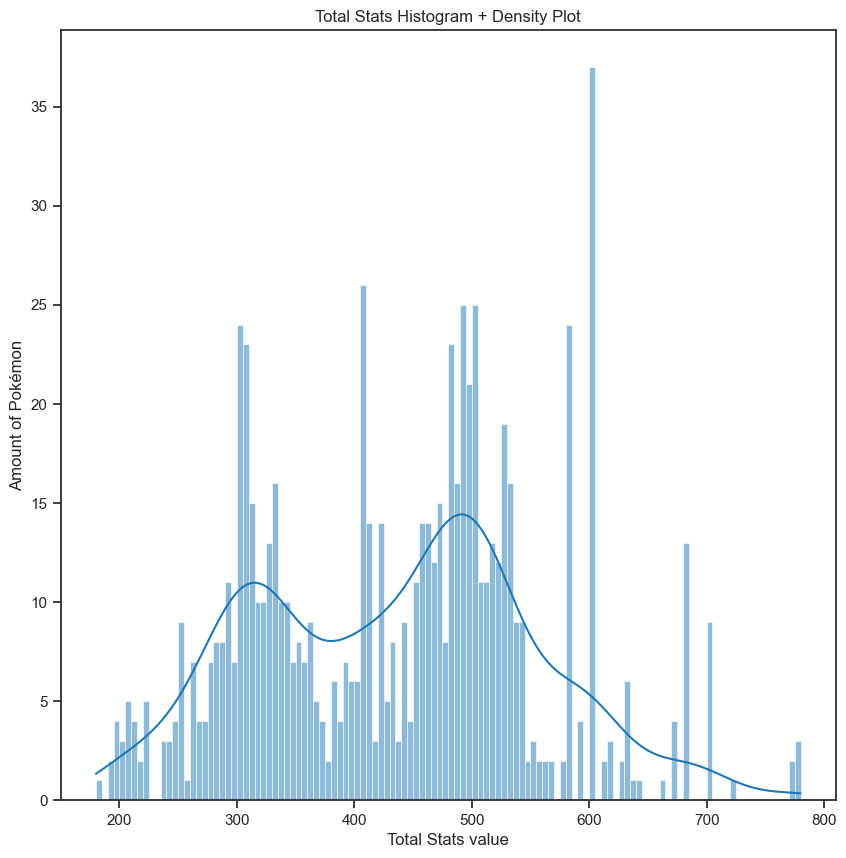

In [ ]:
sns.set_theme(style="ticks", palette=None)
plt.rcParams['figure.figsize'] = [14, 10]
plt.rcParams['figure.dpi'] = 100

fig, ax = plt.subplots()

sns.histplot(data, x='TotalStats', bins=int((data['TotalStats'].max()-data['TotalStats'].min())/5), kde=True)  

plt.xlabel("Total Stats value")
plt.ylabel("Amount of Pokémon")
plt.title("Total Stats Histogram + Density Plot")
plt.show()
# fig.savefig('../Images/Graphics/TotalStastsHistDens.png', bbox_inches='tight')

<span style = "font-family: Verdana; font-size: 20px">

**Weight and Height**

In [ ]:
import plotly.express as px

# Tính toán mật độ (số lượng Pokemon có cùng chiều cao/cân nặng)
# Việc này giúp gán màu sắc dựa trên mật độ điểm
data['Count'] = data.groupby(['Weight', 'Height'])['Weight'].transform('count')

fig = px.scatter(data, 
                 x = 'Weight', 
                 y = 'Height',
                 color = 'Count', # Dùng cột Count vừa tạo để tô màu
                 title='Pokémon Weight vs Height',
                 log_x=True,
                 log_y=True,
                 opacity=0.7, # Giúp nhìn rõ hơn khi các điểm chồng lên nhau
                 color_continuous_scale='Viridis', # Bảng màu dễ nhìn, khoa học
                 labels = dict(
                     Weight = 'Weight (kg)',
                     Height = 'Height (m)',
                     Count = 'Density' # Đổi tên hiển thị trên thanh màu
                 ))

fig.update_layout(
    title = dict(
        text = '<b>Pokémon Weight vs Height Distribution</b>', # In đậm tiêu đề
        font = dict(size=20),
        y=0.95
    ),
    # Cấu hình trục X (Cân nặng) để không bị lỗi lặp số
    xaxis = dict(
        title = dict(text='Weight (kg) - Log Scale', font=dict(size=14)),
        tickvals = [0.1, 1, 10, 100, 1000], # Cố định các mốc giá trị
        ticktext = ["0.1", "1", "10", "100", "1000"] # Nhãn hiển thị tương ứng
    ),
    # Cấu hình trục Y (Chiều cao)
    yaxis = dict(
        title = dict(text='Height (m) - Log Scale', font=dict(size=14)),
        tickvals = [0.1, 0.5, 1, 2, 5, 10, 20], # Các mốc chiều cao phổ biến
        ticktext = ["0.1", "0.5", "1", "2", "5", "10", "20"]
    ),
    title_x = 0.5,
    width = 1000,
    height = 600,
    # QUAN TRỌNG: Hiển thị lại thanh màu để người xem hiểu ý nghĩa
    coloraxis_showscale = True 
)

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**Evolution Stages**

In [ ]:
evo_data = data[['EvoStage', 'TotalEvoStages']].copy()
evo_data['Evo'] = ''
evo_data.loc[(evo_data['EvoStage'] == 1) & (evo_data['TotalEvoStages'] == 1), 'Evo'] = '1 / 1 (No evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 1) & (evo_data['TotalEvoStages'] == 2), 'Evo'] = '1 / 2 (First stage of 2 evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 2) & (evo_data['TotalEvoStages'] == 2), 'Evo'] = '2 / 2 (Second stage of 2 evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 1) & (evo_data['TotalEvoStages'] == 3), 'Evo'] = '1 / 3 (First stage of 3 evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 2) & (evo_data['TotalEvoStages'] == 3), 'Evo'] = '2 / 3 (Second stage of 3 evolutions)'
evo_data.loc[(evo_data['EvoStage'] == 3) & (evo_data['TotalEvoStages'] == 3), 'Evo'] = '3 / 3 (Third stage of 3 evolutions)'

evo_counts = evo_data['Evo'].value_counts().reset_index()

fig = go.Figure(data=[go.Pie(
    labels=evo_counts['Evo'],
    values=evo_counts['count'],
    hole=0.3,
    textposition='auto'
)])

fig.update_layout(
    title=dict(
        text='<br>Distribution of evolution stages of Pokémons',
        font=dict(size=16)
    ),
    title_x=0.5,
    showlegend=True
)

fig.show()

In [ ]:
leveling_rate_counts = data['LevelingRate'].value_counts().reset_index()
leveling_rate_counts.columns

Index(['LevelingRate', 'count'], dtype='object')

<span style = "font-family: Verdana; font-size: 20px">

**Evolution Lines**

In [ ]:
nwk = nx.DiGraph()
# print(nwk.is_directed())

for i in range(len(data)):
    nwk.add_node(data["Name"][i])   # Add Pokémon's name nodes
    if data["PreevoName"][i] != "No Preevolution":
        nwk.add_edge(data["PreevoName"][i], data["Name"][i])
# print(nwk)

pos = nx.spring_layout(nwk)
# print(pos)

# Egde formation
edge_x = []
edge_y = []
# print(nwk.edges())
for edge in nwk.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)
    
edge_trace = go.Scatter(
    x = edge_x, y = edge_y,
    line = dict(
        width=0.5, 
        color='#000000'
        ),
    hoverinfo = 'none',
    mode = 'lines'
)

node_x = []
node_y = []
for node in nwk.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    
node_trace = go.Scatter(
    x = node_x, y = node_y,
    mode = 'markers',
    hoverinfo = 'text',
    marker=dict(
        showscale = True,
        colorscale = 'PuBu',
        reversescale = True,
        color = [],
        size = 10,
        colorbar = dict(
            title = dict(
                text = 'Node Connections',
                side = 'right'
            ),
            xanchor = 'left',
        ),
        line_width = 1
    )
)

print(nwk)

# Color node
node_adjacencies = []
node_text = []
for node, adjacencies in enumerate(nwk.adjacency()):
    node_adjacencies.append(len(adjacencies[1]))
    node_text.append(f"Pokémon\'s name: {str(list(nwk)[node])}<br># of diffent evolutions: {str(len(adjacencies[1]))}")

node_trace.text = node_text
node_trace.marker.color = node_adjacencies #type: ignore

# Network
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title=dict(
                        text = '<br>Pokémon Evolution Network',
                        font = dict(size=16)
                    ),
                    showlegend = False,
                    hovermode = 'closest',
                    # marker = dict(
                    #     color = node_adjacencies
                    # ),
                    margin = dict(
                        b=20,l=5,r=5,t=40
                    ),
                    annotations=[
                        dict(
                            text = "Visualization Project",
                            showarrow = False,
                            xref = "paper",
                            yref = "paper",
                            x = 0.005,
                            y = -0.002
                        )
                    ],
                    xaxis = dict(
                        showgrid = False,
                        zeroline = False,
                        showticklabels = False
                    ),
                    yaxis = dict(
                        showgrid = False,
                        zeroline = False,
                        showticklabels = False
                    )
                )
            )
fig.update_layout(autosize = False,
                  width = 1000,
                  height = 1000)
fig.show()


DiGraph with 805 nodes and 413 edges


<span style = "font-family: Verdana; font-size: 20px">

**DamageFromTypes**

In [ ]:
damage_cols = [col for col in data.columns if col.startswith('DamageFrom')]

for damage_col in damage_cols:
    type_name = damage_col.replace('DamageFrom', '')
    
    damage_counts = data[damage_col].value_counts().sort_index()
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=damage_counts.index,
        y=damage_counts.values,
        fill='tozeroy',
        mode='lines+markers',
        line=dict(color=COLOR_TYPES.get(type_name, '#000000'), width=2),
        marker=dict(size=8),
        name=type_name
    ))
    
    fig.update_layout(
        title=dict(
            text=f'<br>Distribution of Damage Multiplier from {type_name}',
            font=dict(size=16)
        ),
        xaxis_title=dict(text='Damage Multiplier'),
        yaxis_title=dict(text='Count'),
        title_x=0.5,
        xaxis=dict(
            tickmode='array',
            tickvals=[0, 0.25, 0.5, 1, 1.5, 2, 4]
        ),
        height=500,
        showlegend=False
    )
    
    fig.show()


<span style = "font-family: Verdana; font-size: 20px">

**Win Rate of Legendary/Mythical and Mega Evolutions vs Normal Pokémon**

In [ ]:
status_stats = data.copy()
status_stats['Status'] = np.select(
    [
        (status_stats['IsLegendary'] == 1),
        (status_stats['IsMythical'] == 1)
    ],
    [
        'Legendary',
        'Mythical'
    ],
    default='Normal'
)

winrate_stats = status_stats.groupby('Status').agg({
    'WinPercentage': 'mean',
    'FightsWon': 'sum',
    'TotalFights': 'sum'
}).reset_index()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=winrate_stats['Status'],
    y=winrate_stats['WinPercentage'],
    marker=dict(color=['#3498db', '#e74c3c', '#9b59b6']),
    text=winrate_stats['WinPercentage'].round(4),
    textposition='auto',
    texttemplate='%{text:.2%}'
))

fig.update_layout(
    title=dict(
        text='<br>Average Win Rate: Legendary & Mythical vs Normal Pokémon',
        font=dict(size=16)
    ),
    xaxis_title=dict(text='Pokémon Group'),
    yaxis_title=dict(text='Average Win Rate'),
    title_x=0.5,
    yaxis=dict(tickformat='.0%')
)

fig.show()

In [ ]:
mega_mask = (data['IsMega'] == 1) & (data['IsLegendary'] == 0) & (data['IsMythical'] == 0)
non_mega_mask = (data['IsMega'] == 0) & (data['IsLegendary'] == 0) & (data['IsMythical'] == 0)

mega_winrate = data.loc[mega_mask, 'WinPercentage'].mean()
non_mega_winrate = data.loc[non_mega_mask, 'WinPercentage'].mean()

winrate_df = pd.DataFrame({
    'Group': ['Mega Evolution', 'Other (Non-Legendary/Mythical)'],
    'Average Win Rate': [mega_winrate, non_mega_winrate]
})

fig = go.Figure(data=[go.Bar(
    x=winrate_df['Group'],
    y=winrate_df['Average Win Rate'],
    marker=dict(color=['#ea00ff', '#9fa19f']),
    text=winrate_df['Average Win Rate'].round(4),
    textposition='auto',
    texttemplate='%{text:.2%}'
)])

fig.update_layout(
    title=dict(
        text='<br>Average Win Rate: Mega Evolution vs Other Pokémon (Excluding Legendary/Mythical)',
        font=dict(size=16)
    ),
    xaxis_title=dict(text='Pokémon Group'),
    yaxis_title=dict(text='Average Win Rate'),
    title_x=0.5,
    yaxis=dict(tickformat='.0%')
)

fig.show()

In [ ]:
fig = px.scatter(
    data, 
    x="TotalStats", 
    y="WinPercentage",
    trendline="ols", # Quan trọng: Vẽ đường hồi quy tuyến tính (Ordinary Least Squares)
    title="Linear Relationship: Total Stats vs Win Percentage",
    labels={
        "TotalStats": "Total Base Stats", 
        "WinPercentage": "Win Rate (%)"
    }
)

# 3. TÙY CHỈNH MÀU SẮC VÀ GIAO DIỆN
fig.update_traces(
    # Chỉnh các điểm (Markers)
    marker=dict(
        size=6, 
        color='#3690a4', # Màu xanh cổ vịt bạn thích
        opacity=0.6      # Làm mờ một chút để thấy được chỗ nào dữ liệu dày đặc
    ),
    # Chỉnh đường xu hướng (Trendline)
    line=dict(color='red', width=3), # Đường màu đỏ đậm
    selector=dict(mode='lines')      # Chỉ áp dụng màu đỏ cho đường kẻ (không áp dụng cho điểm)
)

fig.update_layout(
    plot_bgcolor='white',
    width=900, height=600,
    title_x=0.5,
    title_font_size=18,
    margin=dict(t=50, b=50, l=50, r=50)
)

# Thêm viền đen
fig.update_xaxes(showline=True, linewidth=1, linecolor='black', mirror=True, gridcolor='lightgray')
fig.update_yaxes(showline=True, linewidth=1, linecolor='black', mirror=True, gridcolor='lightgray')

fig.show()

results = px.get_trendline_results(fig)
print(results.px_fit_results.iloc[0].summary())

<span style = "font-family: Verdana; font-size: 20px">

##### **Categorical Features**

<span style = "font-family: Verdana; font-size: 20px">

**Type**

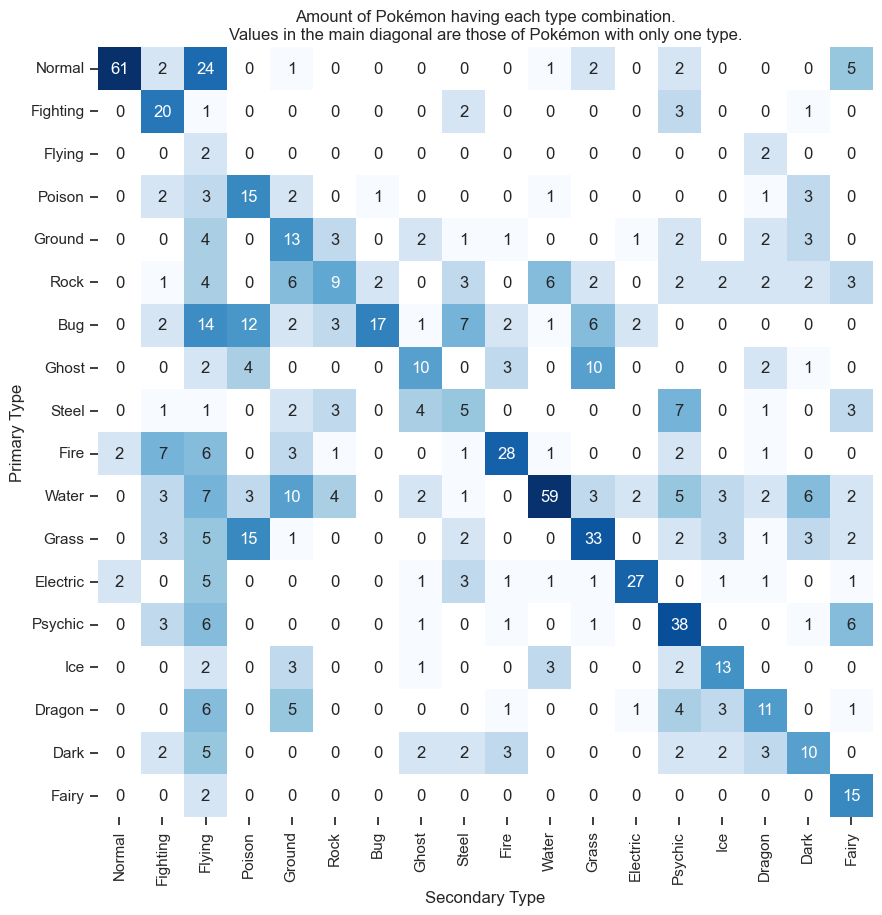

In [ ]:
type_matrix = data.groupby(['Type1','Type2']).size().unstack(fill_value=0)
type_matrix = type_matrix[COLOR_TYPES.keys()].loc[COLOR_TYPES.keys()] #type: ignore
 
# mask = np.triu(np.ones(type_matrix.shape, dtype=bool), k=1)

cmap = plt.colormaps.get_cmap('Blues').copy()
cmap.set_bad('white')
cmap.set_under('white')

plt.title("Amount of Pokémon having each type combination.\nValues in the main diagonal are those of Pokémon with only one type.")
sns.heatmap(type_matrix, annot=True, cmap=cmap, norm=LogNorm(), cbar=False)
plt.ylabel("Primary Type")
plt.xlabel("Secondary Type")
plt.show()

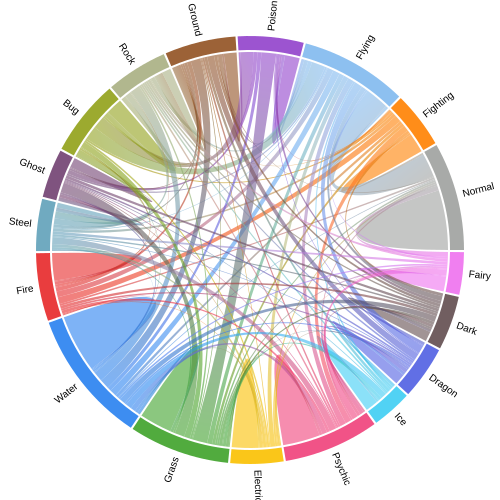

In [ ]:
adjacency_matrix = type_matrix.copy()

for i in range(len(type_matrix)):
    for j in range(len(type_matrix)):
        if not j == i:
            adjacency_matrix.loc[type_matrix.keys()[i], type_matrix.keys()[j]] += type_matrix[type_matrix.keys()[i]][type_matrix.keys()[j]]


labels = list(COLOR_TYPES.keys())

fig = ocd.Chord(adjacency_matrix, labels)
fig.colormap = list(COLOR_TYPES.values())

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**Abilities**

In [ ]:
from tempfile import template


all_ability = []
for abi in ['Ability1', 'Ability2', 'HiddenAbility']:
    all_ability.extend(data[abi].unique().tolist())
    
all_ability = list(set(all_ability))
all_ability.remove('None')

print(f'Number of unique abilities: {len(all_ability)}')

all_ability_name_dict = {x: [] for x in all_ability}
for i in range(data.shape[0]):
    for abi_type in ['Ability1', 'Ability2', 'HiddenAbility']:
        x = data.at[i, abi_type]
        if not x == "None":
            all_ability_name_dict[x].append(data.at[i, 'Name'])
            
# print(all_ability_name_dict)

# Ability used by x Pokémon
amount_dict = {}
for  i in range(1, np.array([len(a) for a in all_ability_name_dict.values()]).max() + 1):
    amount_dict[i] = 0
    for key, value in all_ability_name_dict.items():
        if len(value) == i:
            amount_dict[i] += 1
            
# print(amount_dict)
for i in amount_dict.keys():
    print(i, [k for k, v in all_ability_name_dict.items() if len(v) == i]
)
    
df = pd.DataFrame(list(amount_dict.items()), columns=['Number of Pokémon', 'Number of Abilities'])

colorscale = 'Plasma'
normalized_heights = (df['Number of Abilities'] - df['Number of Abilities'].min()) / (df['Number of Abilities'].max() - df['Number of Abilities'].min()) # MinMaxScaling method

fig = go.Figure(data=[
        go.Bar(
            x = df['Number of Pokémon'],
            y = df['Number of Abilities'],
            marker = dict(
                color = normalized_heights,
                colorscale = colorscale,
                # showscale = True, # Interactive chart so unnessary
            )
        )
    ]
)

fig.update_layout(
    title = dict(
        text = f'<br>Number of Abilities used by certain number of Pokémon',
        font = dict(size=16)
    ),
    yaxis_title = dict(text='Number of Abilities'),
    xaxis_title = dict(text='Number of Pokémon'),
    title_x = 0.5,
    bargap = 0.1,
)

fig.show()
fig.write_image(f"../Images/Graphics/AbilitiesPokemon.png")

Number of unique abilities: 196
1 ['Desolate Land', 'Imposter', 'Air Lock', 'Bad Dreams', 'Power Construct', 'Slow Start', 'Multitype', 'Sharpness', 'Victory Star', 'Aura Break', 'Wind Rider', 'Fairy Aura', 'Parental Bond', 'Toxic Boost', 'Fur Coat', 'Color Change', 'Dark Aura', 'Flower Gift', 'Wonder Guard', 'Stall', 'Primordial Sea', 'Delta Stream', 'Forecast']
2 ['Honey Gather', 'Normalize', 'Iron Barbs', 'Multiscale', 'Heatproof', 'Turboblaze', 'Stance Change', 'White Smoke', 'Neutralizing Gas', 'Aerilate', 'Aroma Veil', 'Zen Mode', 'Mummy', 'Illusion', 'Sweet Veil', 'Flare Boost', 'Teravolt', 'Grass Pelt', 'Slush Rush', 'Defeatist']
3 ['Marvel Scale', 'Pixilate', 'Pure Power', 'Bulletproof', 'Flower Veil', 'Truant', 'Symbiosis', 'Gale Wings', 'Refrigerate', 'Magma Armor', 'Mega Launcher', 'Poison Heal', 'Drizzle', 'Cheek Pouch', 'Gooey', 'Strong Jaw', 'Immunity', 'Arena Trap', 'Filter']
4 ['Protean', 'Wonder Skin', 'Motor Drive', 'Download', 'Liquid Ooze', 'Solid Rock']
5 ['Heavy 

<span style = "font-family: Verdana; font-size: 20px">

**Pokémon Egg Group**

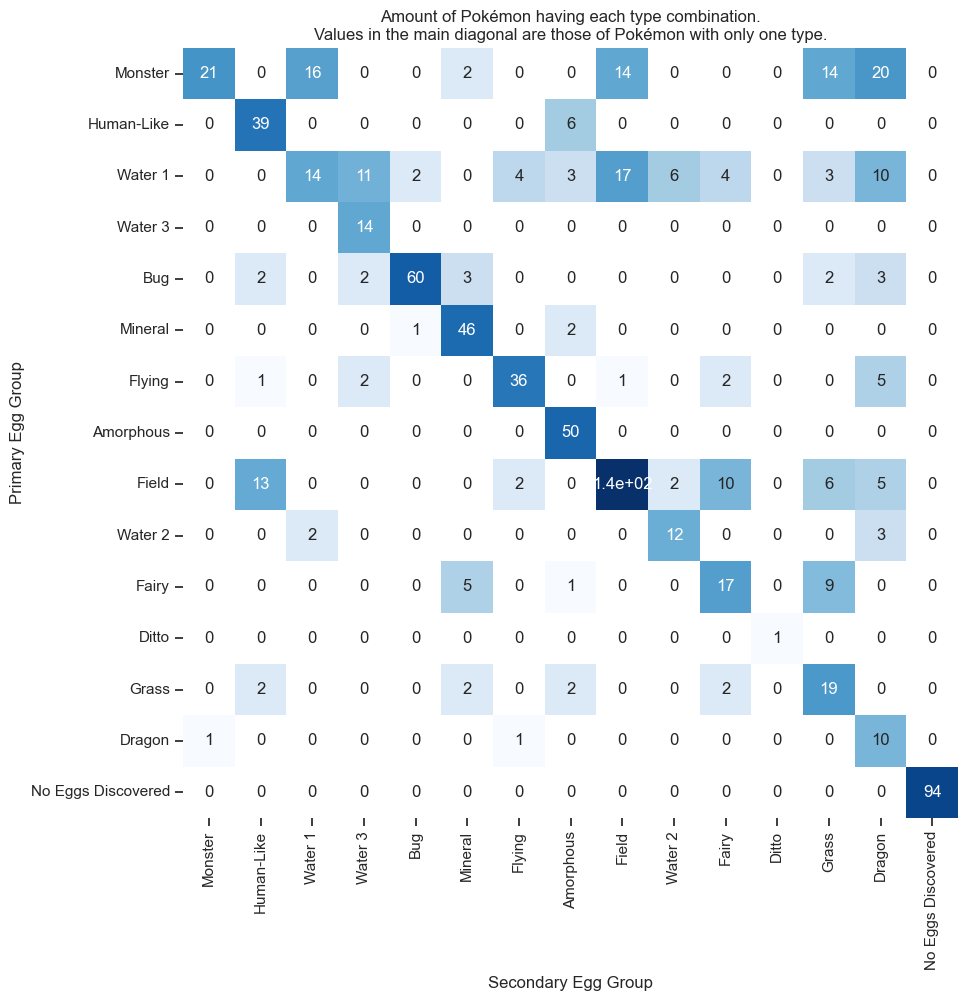

In [ ]:
mask = (data['EggGroup2'] == 'No Eggs Discovered') & (data['EggGroup1'] != 'No Eggs Discovered')
data.loc[mask, 'EggGroup2'] = data.loc[mask, 'EggGroup1']
egg_matrix = data.groupby(['EggGroup1','EggGroup2']).size().unstack(fill_value=0)
egg_matrix = egg_matrix[COLOR_EGGGROUPS.keys()].loc[COLOR_EGGGROUPS.keys()] #type:ignore

cmap = plt.colormaps.get_cmap('Blues').copy()
cmap.set_bad('white')      # color of mask on heatmap
cmap.set_under('white')    # color of mask on cbar

plt.title("Amount of Pokémon having each type combination.\nValues in the main diagonal are those of Pokémon with only one type.")
sns.heatmap(egg_matrix, annot=True, cmap=cmap, norm=LogNorm(), cbar=False)
plt.ylabel("Primary Egg Group")
plt.xlabel("Secondary Egg Group")
plt.show()

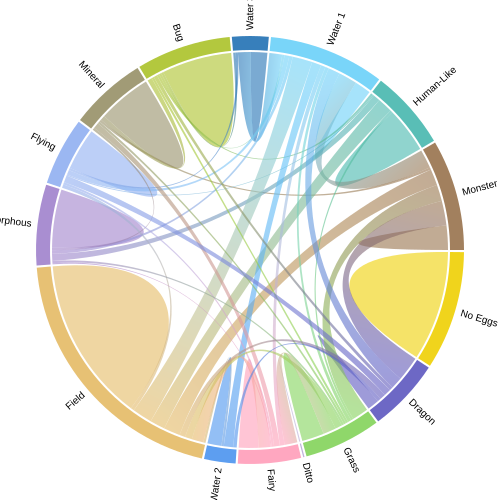

In [ ]:
adjacency_matrix = egg_matrix.copy()

for i in range(len(egg_matrix)):
    for j in range(len(egg_matrix)):
        if not j == i:
            adjacency_matrix.loc[egg_matrix.keys()[i], egg_matrix.keys()[j]] += egg_matrix[egg_matrix.keys()[i]][egg_matrix.keys()[j]]


labels = list(COLOR_EGGGROUPS.keys())

fig = ocd.Chord(adjacency_matrix, labels)
fig.colormap = list(COLOR_EGGGROUPS.values())

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**LevelingRate**

In [ ]:
leveling_rate_counts = data['LevelingRate'].value_counts().reset_index()
leveling_rate_counts.columns = ['LevelingRate', 'Count']

fig = go.Figure(data=[go.Pie(
    labels=leveling_rate_counts['LevelingRate'],
    values=leveling_rate_counts['Count'],
    hole=0.3,
    textinfo='label+percent',
    textposition='auto'
)])

fig.update_layout(
    title=dict(
        text='<br>Distribution of Pokémon by Leveling Rate',
        font=dict(size=16)
    ),
    title_x=0.5,
    showlegend=True
)

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**Category**

<span style = "font-family: Verdana; font-size: 20px">

**Rarity**

In [ ]:
status_counts = {
    'Normal': (data['IsLegendary'] == 0) & (data['IsMythical'] == 0),
    'Legendary': (data['IsLegendary'] == 1),
    'Mythical': (data['IsMythical'] == 1)
}

status_df = pd.DataFrame({
    'Status': ['Normal', 'Legendary', 'Mythical'],
    'Count': [status_counts['Normal'].sum(), status_counts['Legendary'].sum(), status_counts['Mythical'].sum()]
})

fig = go.Figure(data=[go.Pie(
    labels=status_df['Status'],
    values=status_df['Count'],
    hole=0.3,
    textinfo='label+percent',
    textposition='auto'
)])

fig.update_layout(
    title=dict(
        text='<br>Distribution of Pokémon by Rarity',
        font = dict(size = 16),
        automargin=True
    ),
    title_x=0.5,
    showlegend=True,
)

fig.show()